Distinguishing causality from coincidence is not very important in predictive analysis tasks since you do not influence the system. However, when you try to manipulate the system and use your model for decision making, you meet fundamental problems. If the model does not take in account causal relations, you fail to accurately predict an outcome after intervention.

## Simple motivating example
For example imagine a situation when government met the following fact: students who have good marks at school are good in profession later. So the better student is the better society lives. Talent and a lot of other facts are not taken in account, however. What should we do to make better future for people? 

If no intervention is done school success is a good predictor for career. But we know, correlation does not mean causation. This example demonstrates this principle in an intuitive way. If we manipulate school grading system that will change nothing in future.

In [1]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
N = 100
talentd = st.gamma(4)
talent = talentd.rvs(size=N)
stress_at_school = np.random.normal(0, .5, size=N)
stress_at_work = np.random.normal(0, 1.2, size=N)
school_success = talent+stress_at_school
criteria_at_school = np.percentile(school_success, np.arange(0, 100, 10))
grade_at_school = np.searchsorted(criteria_at_school, school_success)
salary_at_work = 100+np.log(1+np.exp(talent+stress_at_work))

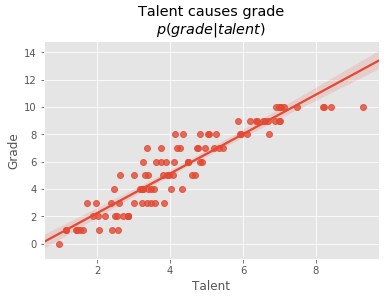

In [3]:
sns.regression.regplot(talent, grade_at_school)
plt.xlabel('Talent')
plt.ylabel('Grade')
plt.title('Talent causes grade\n$p(grade|talent)$');

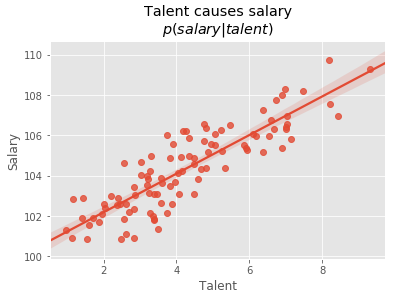

In [4]:
sns.regression.regplot(talent, salary_at_work)
plt.xlabel('Talent')
plt.ylabel('Salary')
plt.title('Talent causes salary\n$p(salary|talent)$');

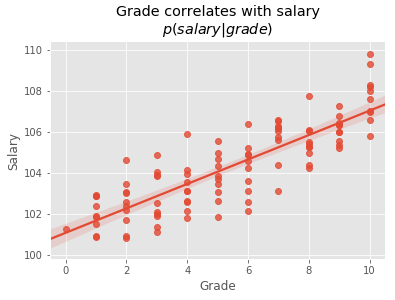

In [5]:
sns.regression.regplot(grade_at_school, salary_at_work)
plt.xlabel('Grade')
plt.ylabel('Salary')
plt.title('Grade correlates with salary\n$p(salary|grade)$');

What if we manipulate grades thinking that correlation is causation in our case? Notation for manipulation some variable is usually `do(variable=value)`

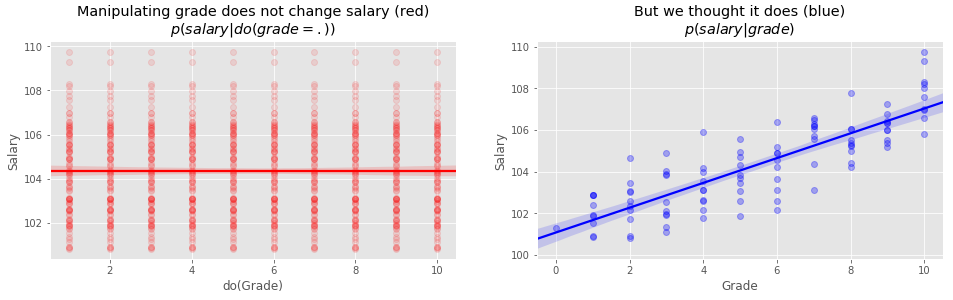

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

sns.regression.regplot(
    np.concatenate([
        np.ones_like(salary_at_work)*i for i in range(1, 11)
    ]), # manually changed grade
    np.concatenate([salary_at_work]*10),
    ax=ax[0], color='r', scatter_kws=dict(alpha=.1)
)
sns.regression.regplot(grade_at_school, salary_at_work, ax=ax[1], color='b', scatter_kws=dict(alpha=.3))
ax[0].set_xlabel('do(Grade)')
ax[0].set_ylabel('Salary')
ax[0].set_title('Manipulating grade does not change salary (red)\n$p(salary|do(grade=.))$');
ax[1].set_xlabel('Grade')
ax[1].set_ylabel('Salary')
ax[1].set_title('But we thought it does (blue)\n$p(salary|grade)$');

## Traditional approach vs structured modelling?
Traditional approach usually builds a model that looks like $p(y|X)$ and underlying causal mechanisms are hidden. So only conditional can be inferred and can't be used for policy decisions is causal mechanisms are broken inside like in example above. What is challenging is inferring causal channels by hand or automatically. Once you infer such a channel you are able to estimate structured model that respects given causal structure. In grade salary model we assumed that grade causes salary, but model knew nothing about it. Model did all right and fools us unintentionally.

## What to do?
In most of domains inferring causal structure is challenging. Take economics for example. There exist a lot of theoretical works on simple topics like monetary policy. Influence channel can be explained in different non mutually exclusive ways. Sometimes researches get controversial results estimating same causal structure. Of course building `model of everything` is not always possible. From the other hand we can use not single point estimate but recover Bayesian posterior over models and perform model averaging for policy decisions. That approach looks much mode reasonable as it covers different points of views.